In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Vectors

### Vector Decomposition

In [2]:
# Defining the vectors
t = np.random.randint(1, 10, 2)
r = np.random.randint(1, 10, 2)

# Computing
r_unit = r / np.linalg.norm(r)
t_parallel = np.dot(t, r_unit) * r_unit
t_perpendicular = t - t_parallel

print("Original vector t:", t)
print("Original vector r:", r)
print("Parallel component (along r):", t_parallel)
print("Orthogonal component:", t_perpendicular)

# Checking to see if sum of components equals original vector
print("Sum of components:", t_parallel + t_perpendicular)

Original vector t: [6 3]
Original vector r: [1 5]
Parallel component (along r): [0.80769231 4.03846154]
Orthogonal component: [ 5.19230769 -1.03846154]
Sum of components: [6. 3.]


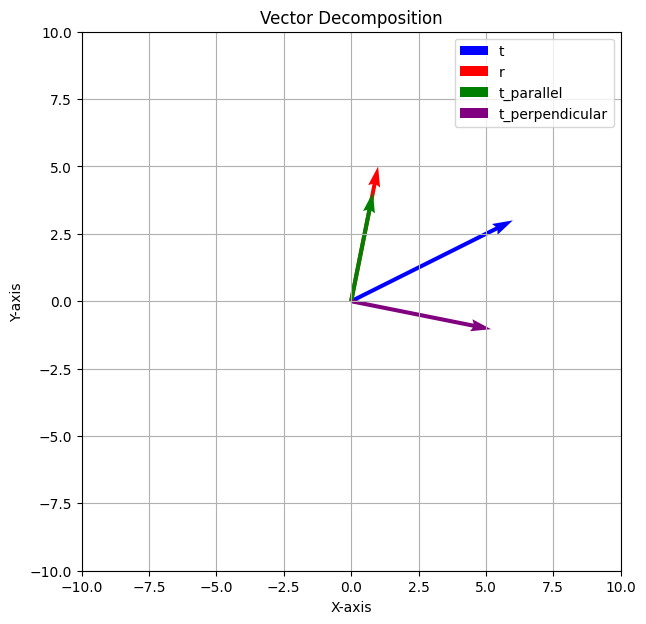

In [3]:
# Plotting the vectors
plt.figure(figsize=(7, 7))
plt.quiver(0, 0, t[0], t[1], angles='xy', scale_units='xy', scale=1, color='b', label='t')
plt.quiver(0, 0, r[0], r[1], angles='xy', scale_units='xy', scale=1, color='r', label='r')
plt.quiver(0, 0, t_parallel[0], t_parallel[1], angles='xy', scale_units='xy', scale=1, color='g', label='t_parallel')
plt.quiver(0, 0, t_perpendicular[0], t_perpendicular[1], angles='xy', scale_units='xy', scale=1, color='purple', label='t_perpendicular')

# Setting plot limits and labels
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Vector Decomposition')
plt.grid()
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')

# Show the plot
plt.show()

### Linear Combination of Vectors

In [4]:
# Define the lists
scalar_list = [2, -3, 1.5]
vector_list = [np.array([1, 2, 3]), np.array([4, 5, 6]), np.array([-1, 0, 1])]

# Computing the linear combination
output_vector = np.zeros(vector_list[0].shape)
for i in range(len(scalar_list)):
  output_vector += scalar_list[i] * vector_list[i]

print("Scalars:", scalar_list)
print("Vectors:", vector_list)
print("Result of linear weighted combination:", output_vector)

Scalars: [2, -3, 1.5]
Vectors: [array([1, 2, 3]), array([4, 5, 6]), array([-1,  0,  1])]
Result of linear weighted combination: [-11.5 -11.  -10.5]


We can try out two more special cases of linear combination of vectors

In [5]:
# 1: Adding more scalars and vectors
scalars_1 = [2, -3, 1.5, 4, -1]
vectors_1 = [np.array([1, 2]), np.array([4, 5]), np.array([-1, 0]), np.array([2, -2]), np.array([3, 3])]

output_vector_1 = np.zeros(vectors_1[0].shape)
for i in range(len(scalars_1)):
  output_vector_1 += scalars_1[i] * vectors_1[i]
print("Scalars:", scalars_1)
print("Vectors:", vectors_1)
print("Linear weighted combination:", output_vector_1)

Scalars: [2, -3, 1.5, 4, -1]
Vectors: [array([1, 2]), array([4, 5]), array([-1,  0]), array([ 2, -2]), array([3, 3])]
Linear weighted combination: [ -6.5 -22. ]


In [7]:
# 2. More vectors than scalars
scalars_4 = [2, -3]
vectors_4 = [np.array([1, 2]), np.array([4, 5]), np.array([-1, 0])]

output_vector_4 = np.zeros(vectors_4[0].shape)
for i in range(len(scalars_4)):
  output_vector_4 += scalars_4[i] * vectors_4[i]
print("Scalars:", scalars_4)
print("Vectors:", vectors_4)
print("Linear weighted combination:", output_vector_4)

Scalars: [2, -3]
Vectors: [array([1, 2]), array([4, 5]), array([-1,  0])]
Linear weighted combination: [-10. -11.]


### Correlation and Cosine Similarity

In [8]:
def Corr_Cos_Func(x,y):

  # correlation
  xMean  = x-np.mean(x)
  yMean  = y-np.mean(y)
  n1 = np.dot(xMean,yMean)
  cor = n1/(np.linalg.norm(xMean) * np.linalg.norm(yMean))

  # cosine similarity
  n2 = np.dot(x,y)
  cos = n2 / (np.linalg.norm(x) * np.linalg.norm(y))

  return cor, cos

In [9]:
v = np.linspace(0, 3, 4)
step = np.arange(-50,51)
final = np.zeros((len(step),2))

for i in range(len(step)):
    final[i,:] = Corr_Cos_Func(v,v+step[i])

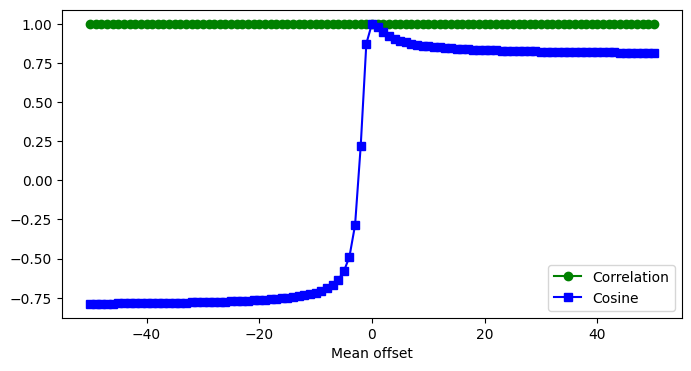

In [10]:
# plotting
plt.figure(figsize=(8, 4))
lines = plt.plot(step, final)

lines[0].set(color='green', marker = 'o')
lines[1].set(color='blue', marker = 's')

plt.xlabel('Mean offset')
plt.legend(['Correlation', 'Cosine'])
plt.show()

Smoothing & Sharpening Time Series Functions

In [16]:
# Define kernel and time series
smoothing_kernel = np.array([0, 0.1, 0.3, 0.8, 1, 0.8, 0.3, 0.1, 0])
smoothing_kernel /= smoothing_kernel.sum()
signal_length = 100
signal = np.random.randn(signal_length)

# Using convolve here to filter
filtered_signal = np.convolve(signal, smoothing_kernel, mode='same')

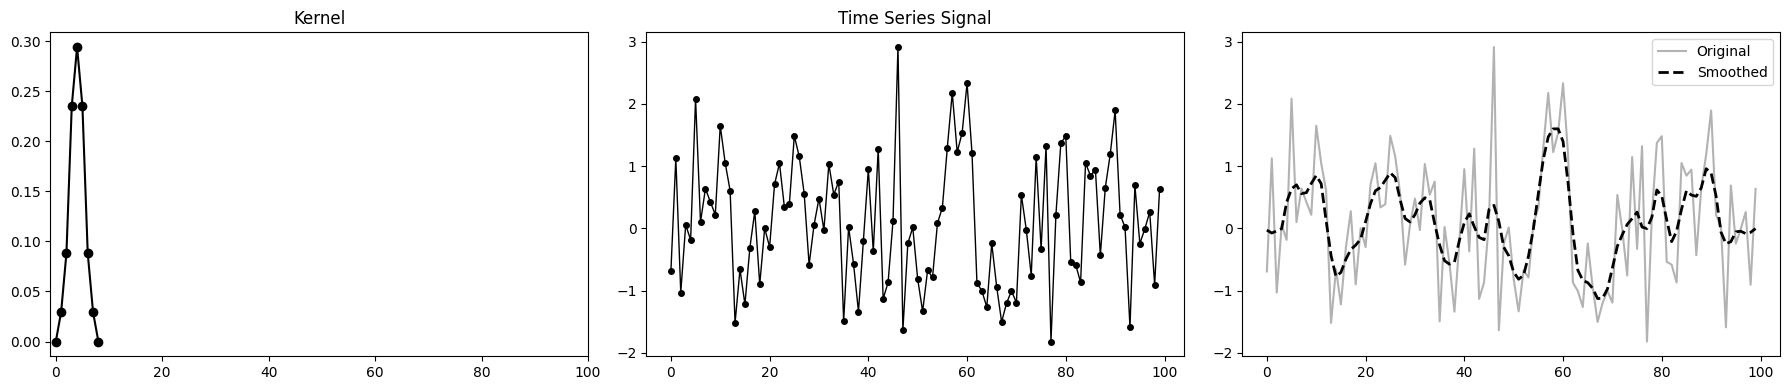

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# kernel
axes[0].plot(smoothing_kernel,'ko-')
axes[0].set_title('Kernel')
axes[0].set_xlim(-1, 100)

# time series
axes[1].plot(signal, color='black', marker='o', markersize=4, linewidth=1)
axes[1].set_title('Time Series Signal')

# smoothed signal
axes[2].plot(signal, color='gray', alpha=0.6, label='Original')
axes[2].plot(filtered_signal, color='black', linestyle='--', linewidth=2, label='Smoothed')
axes[2].legend()

plt.tight_layout()
plt.show()

In [18]:
# Define a sharpening kernel (edge enhancer)
sharpening_kernel = np.array([0, 0.1, 0.3, 0.8, -1, 0.8, 0.3, 0.1, 0])
sharpening_kernel /= sharpening_kernel.sum()
sharpening_kernel -= sharpening_kernel.mean()

# Generate a random signal
signal_length = 100
signal = np.random.randn(signal_length)

# Apply the kernel using convolution
filtered_signal = np.convolve(signal, sharpening_kernel, mode='same')

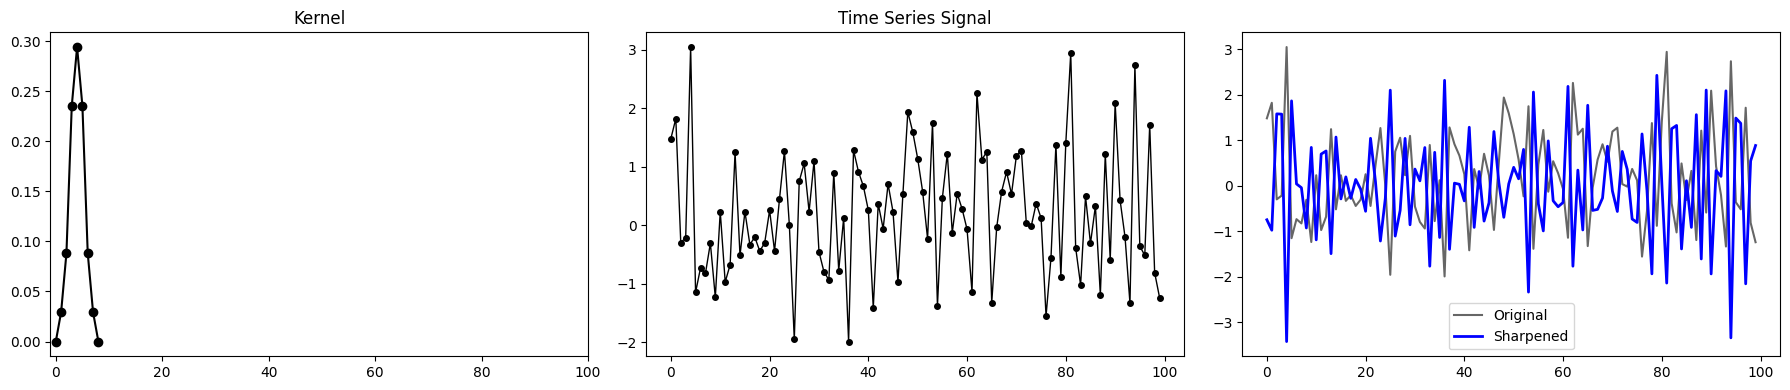

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot the sharpening kernel
axes[0].plot(smoothing_kernel,'ko-')
axes[0].set_title('Kernel')
axes[0].set_xlim(-1, 100)

# Plot the raw signal
axes[1].plot(signal, color='black', marker='o', markersize=4, linewidth=1)
axes[1].set_title('Time Series Signal')

# Plot the sharpened signal
axes[2].plot(signal, color='black', alpha=0.6, label='Original')
axes[2].plot(filtered_signal, color='blue', linewidth=2, label='Sharpened')
axes[2].legend()

plt.tight_layout()
plt.show()

### K-Means CLustering

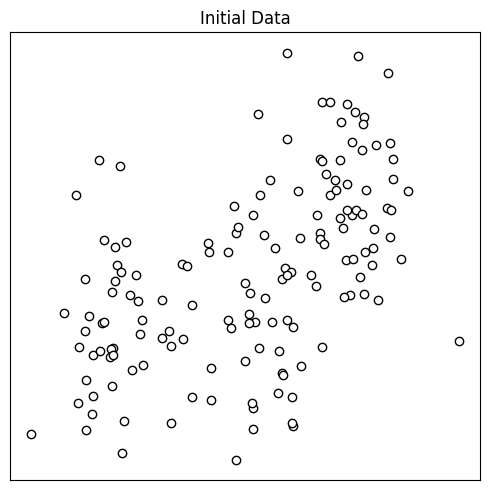

In [11]:
points_per_cluster = 50
spread = 1

# centers
centers = np.array([
    [ 1,  1],
    [-3,  1],
    [ 3,  3]
])

# Generate data around each center
data_a = centers[0] + np.random.randn(points_per_cluster, 2) * spread
data_b = centers[1] + np.random.randn(points_per_cluster, 2) * spread
data_c = centers[2] + np.random.randn(points_per_cluster, 2) * spread

points = np.vstack((data_a, data_b, data_c))

# plot
plt.figure(figsize=(5, 5))
plt.scatter(points[:, 0], points[:, 1], edgecolor='k', facecolor='white')
plt.title('Initial Data')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

In [14]:
num_clusters = 2

# Choosing centroids
initial_indices = np.random.choice(len(points), num_clusters, replace=False)
cluster_centers = points[initial_indices]

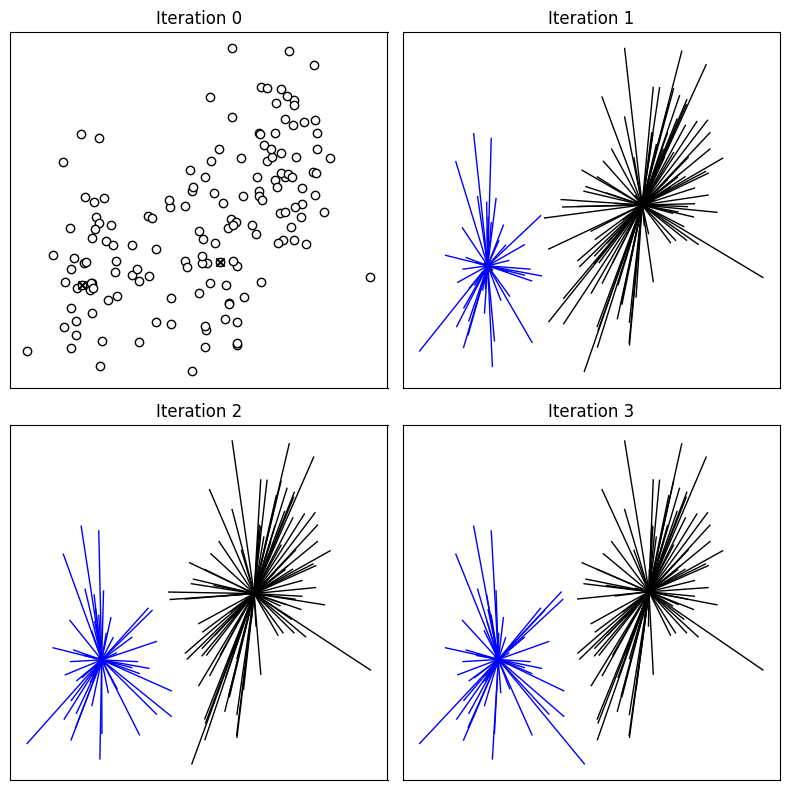

In [15]:
# Setting up plot layout
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()
line_colors = ['black', 'blue', 'gray']

# Plot
axes[0].scatter(points[:, 0], points[:, 1], edgecolor='k', facecolor='white')
axes[0].scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='k', marker='x')
axes[0].set_title('Iteration 0')
axes[0].set_xticks([])
axes[0].set_yticks([])

for step in range(3):
    # Compute squared distances to each center
    distances = np.array([
        np.sum((points - center) ** 2, axis=1)
        for center in cluster_centers
    ]).T

    # Assign each point to the nearest cluster
    assignments = np.argmin(distances, axis=1)

    # Update cluster centers
    for c in range(num_clusters):
        cluster_members = points[assignments == c]
        if len(cluster_members) > 0:
            cluster_centers[c] = cluster_members.mean(axis=0)

    # Plot connections and updated centers
    for i, point in enumerate(points):
        assigned_c = assignments[i]
        axes[step + 1].plot(
            [point[0], cluster_centers[assigned_c, 0]],
            [point[1], cluster_centers[assigned_c, 1]],
            color=line_colors[assigned_c],
            linewidth=1
        )

    axes[step + 1].scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='k', marker='x')
    axes[step + 1].set_title(f'Iteration {step + 1}')
    axes[step + 1].set_xticks([])
    axes[step + 1].set_yticks([])

plt.tight_layout()
plt.show()


## Matrices

### Choosing a sub-matrix

In [20]:
C_matrix = np.arange(100).reshape(10, 10)

C1_submatrix = C_matrix[:5, :5]

print("Original Matrix C:")
print(C_matrix)

# Print the submatrix
print("\nSubmatrix C1 (Top-left 5x5):")
print(C1_submatrix)

Original Matrix C:
[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]
 [60 61 62 63 64 65 66 67 68 69]
 [70 71 72 73 74 75 76 77 78 79]
 [80 81 82 83 84 85 86 87 88 89]
 [90 91 92 93 94 95 96 97 98 99]]

Submatrix C1 (Top-left 5x5):
[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]
 [40 41 42 43 44]]


### Matrix Operations

Let us first check for the commutative and associative properties

In [24]:
A = np.random.randn(3, 4)
B = np.random.randn(3, 4)
s = np.random.randn()

print(A)
print()
print(B)
print()
print(s)

[[-1.90695404 -0.47566898 -0.67876102 -1.26163773]
 [-1.39825539 -0.73164922  0.40229363 -1.36664334]
 [ 1.13372358 -0.83247652 -0.1913312  -1.5828598 ]]

[[-0.37992297 -1.04676314  0.15309521 -0.07185684]
 [ 1.35186414  0.79741004 -0.51490564 -0.20476508]
 [-1.09416287 -1.53096218  0.14288076  1.65016086]]

0.03792065567536567


In [25]:
expr1 = s * (A + B)
expr2 = s * A + s * B
expr3 = A * s + B * s

equal1 = np.allclose(expr1, expr2)
equal2 = np.allclose(expr2, expr3)

In [26]:
# Print result
print("Are the properties satisfied: ", equal1 and equal2)

Are the properties satisfied:  True


The two types of matrix multiplication:

In [27]:
# Diagonal matrices
matrix1 = np.diag(np.random.randn(3))
matrix2 = np.diag(np.random.randn(3))

print(matrix1)
print()
print(matrix2)

[[-0.16202381  0.          0.        ]
 [ 0.         -0.60074688  0.        ]
 [ 0.          0.         -0.37070624]]

[[0.49068844 0.         0.        ]
 [0.         0.91601267 0.        ]
 [0.         0.         1.52203616]]


In [28]:
# two forms of multiplication
hadamard = matrix1*matrix2
standard = matrix1@matrix2
# compare
hadamard - standard

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

### Checking symmetricity

In [21]:
def check_symmetric(matrix):
    close_elements = np.isclose(matrix, matrix.T)
    return np.all(close_elements)

In [22]:
# Random 4x4 matrix
A = np.random.randn(4, 4)
AtA = A.T @ A

print(A)
print()
print(AtA)

[[ 0.20393322  0.56253914  0.627415   -1.6232858 ]
 [ 0.0049248   0.26214782  0.9028562   1.46964055]
 [-0.59769083  0.33857046 -0.73523542 -0.73637128]
 [ 0.35812019 -0.30572517 -0.36345251  0.77162398]]

[[ 0.52709741 -0.19583537  0.44168093  0.39265227]
 [-0.19583537  0.5932696   0.45181487 -1.01311717]
 [ 0.44168093  0.45181487  1.88146775  0.56935779]
 [ 0.39265227 -1.01311717  0.56935779  5.93254636]]


In [23]:
# Checking
print("Is A symmetric?      ", check_symmetric(A))
print("Is A.T @ A symmetric?", check_symmetric(AtA))

Is A symmetric?       False
Is A.T @ A symmetric? True


## Rank of a matrix

In [30]:
def check_matrix_ranks(rows, cols, rank):
    # Step 1: Create matrix
    U = np.random.randn(rows, rank)
    V = np.random.randn(rank, cols)
    A = U @ V

    # Compute
    A_T = A.T
    A_TA = A_T @ A
    AA_T = A @ A_T
    rank_A    = np.linalg.matrix_rank(A)
    rank_AT   = np.linalg.matrix_rank(A_T)
    rank_ATA  = np.linalg.matrix_rank(A_TA)
    rank_AAT  = np.linalg.matrix_rank(AA_T)

    # Print
    print("Matrix :")
    print(np.round(A, 3))
    print(f"\nMatrix shape: A = {A.shape}")
    print(f"Desired rank: {rank}\n")
    print(f"Rank of A       : {rank_A}")
    print(f"Rank of A.T     : {rank_AT}")
    print(f"Rank of A.T @ A : {rank_ATA}")
    print(f"Rank of A @ A.T : {rank_AAT}")

In [31]:
check_matrix_ranks(rows=4, cols=3, rank=3)

Matrix :
[[ 0.278 -0.445  0.308]
 [-0.6    0.445  0.033]
 [ 0.209  0.632 -0.139]
 [ 0.99  -0.696 -1.273]]

Matrix shape: A = (4, 3)
Desired rank: 3

Rank of A       : 3
Rank of A.T     : 3
Rank of A.T @ A : 3
Rank of A @ A.T : 3


In [32]:
check_matrix_ranks(rows=2, cols=10, rank=2)

Matrix :
[[ 0.569 -0.201  1.245  0.59   0.188  1.554  0.482 -1.655  1.074  0.233]
 [ 2.011  0.282 -0.24   1.168  0.552 -1.048 -0.572  0.758 -2.049 -0.965]]

Matrix shape: A = (2, 10)
Desired rank: 2

Rank of A       : 2
Rank of A.T     : 2
Rank of A.T @ A : 2
Rank of A @ A.T : 2


### Determinant of a matrix

In [33]:
min_size = 3
max_size = 30
repeats = 100

avg_determinants = []

In [34]:
for size in range(min_size, max_size + 1):
    det_values = []

    for _ in range(repeats):
        M = np.random.randn(size, size)
        col1, col2 = np.random.choice(size, size=2, replace=False)
        scale = np.random.randn()
        M[:, col1] = M[:, col2] * scale

        det_val = np.abs(np.linalg.det(M))
        det_values.append(det_val)

    avg_determinants.append(np.mean(det_values))

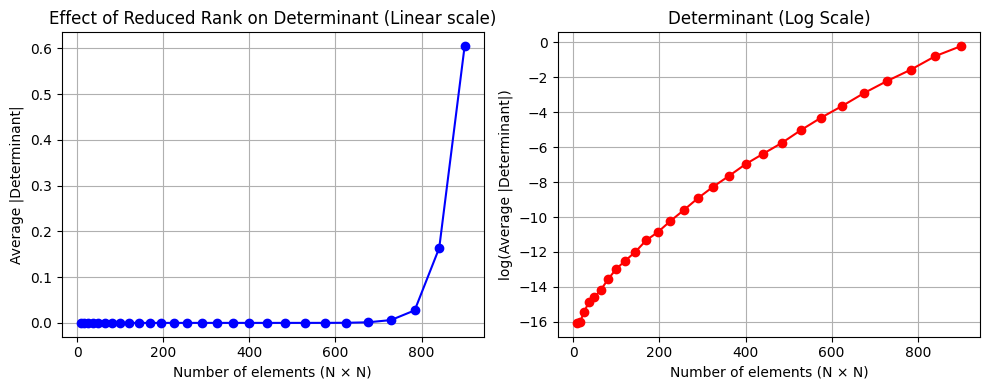

In [35]:
# Plotting

matrix_sizes = list(range(min_size, max_size + 1))
num_elements = [n * n for n in matrix_sizes]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(num_elements, avg_determinants, 'bo-')
plt.xlabel('Number of elements (N × N)')
plt.ylabel('Average |Determinant|')
plt.title('Effect of Reduced Rank on Determinant (Linear scale)')
plt.grid(True)

# Plot 2: Log scale

log_determinants = [np.log10(d) if d > 0 else np.log10(1e-300) for d in avg_determinants]

plt.subplot(1, 2, 2)
plt.plot(num_elements, log_determinants, 'ro-')
plt.xlabel('Number of elements (N × N)')
plt.ylabel('log(Average |Determinant|)')
plt.title('Determinant (Log Scale)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Inverse of a Matrix

In [36]:
matrix = np.random.randn(4,4)

inverse_mat  = np.linalg.inv(matrix)
inv_inv_mat = np.linalg.inv(inverse_mat)

print(matrix)
print()
# To check whether they are equal
np.round(matrix - inv_inv_mat, 5)

[[ 0.33711337  0.84897225  0.75530596 -0.91355189]
 [ 0.0105958   0.77389509  0.26269999  1.21853212]
 [-0.7702038  -0.84952796 -0.13791396 -0.39978385]
 [-0.14152981 -1.21637932  1.52724706 -0.37041902]]



array([[ 0., -0.,  0., -0.],
       [ 0., -0.,  0.,  0.],
       [ 0.,  0., -0.,  0.],
       [ 0.,  0.,  0.,  0.]])

In [37]:
# Create wide matrix
A = np.random.randint(-10, 11, size=(3, 10))
print(A)
print(f'\nRank of A: {np.linalg.matrix_rank(A)}')

[[ -9  -5  -5   5   5   2   9  -6   6  -9]
 [  7   1  -7   4  -7   4   1  -1   0 -10]
 [ -4  -3   5  -5  -8   8  -4  -8   3  -8]]

Rank of A: 3


In [38]:
M = A @ A.T

Minv = np.linalg.inv(M)
print(np.round(Minv @ M, 4))

[[ 1.  0.  0.]
 [-0.  1. -0.]
 [ 0. -0.  1.]]


In [39]:
J = A.T @ Minv
print(np.round(A @ J, 6))
print()
print(np.round(J @ A, 6))

[[ 1. -0.  0.]
 [-0.  1. -0.]
 [ 0. -0.  1.]]

[[ 5.17904e-01  1.98440e-01 -1.93639e-01  8.94010e-02 -2.50016e-01
  -2.34870e-02 -1.25824e-01  2.24448e-01 -1.87875e-01 -1.57260e-02]
 [ 1.98440e-01  9.13350e-02 -4.13130e-02  1.52900e-02 -5.64090e-02
  -5.21310e-02 -6.57920e-02  1.25307e-01 -9.44480e-02  8.26010e-02]
 [-1.93639e-01 -4.13130e-02  3.83484e-01 -2.95477e-01 -4.40790e-02
   4.90450e-02 -2.31158e-01 -8.96000e-02  1.15000e-04  2.10009e-01]
 [ 8.94010e-02  1.52900e-02 -2.95477e-01  2.42631e-01  1.12550e-01
  -7.29740e-02  2.21367e-01  7.30070e-02  1.55290e-02 -1.25143e-01]
 [-2.50016e-01 -5.64090e-02 -4.40790e-02  1.12550e-01  4.27460e-01
  -2.22583e-01  2.37685e-01  7.61650e-02  5.30720e-02  2.23120e-01]
 [-2.34870e-02 -5.21310e-02  4.90450e-02 -7.29740e-02 -2.22583e-01
   1.96186e-01 -7.76890e-02 -1.70848e-01  5.97550e-02 -2.41577e-01]
 [-1.25824e-01 -6.57920e-02 -2.31158e-01  2.21367e-01  2.37685e-01
  -7.76890e-02  2.91190e-01 -9.54100e-03  9.33110e-02 -1.11681e-01]
 [ 2.244

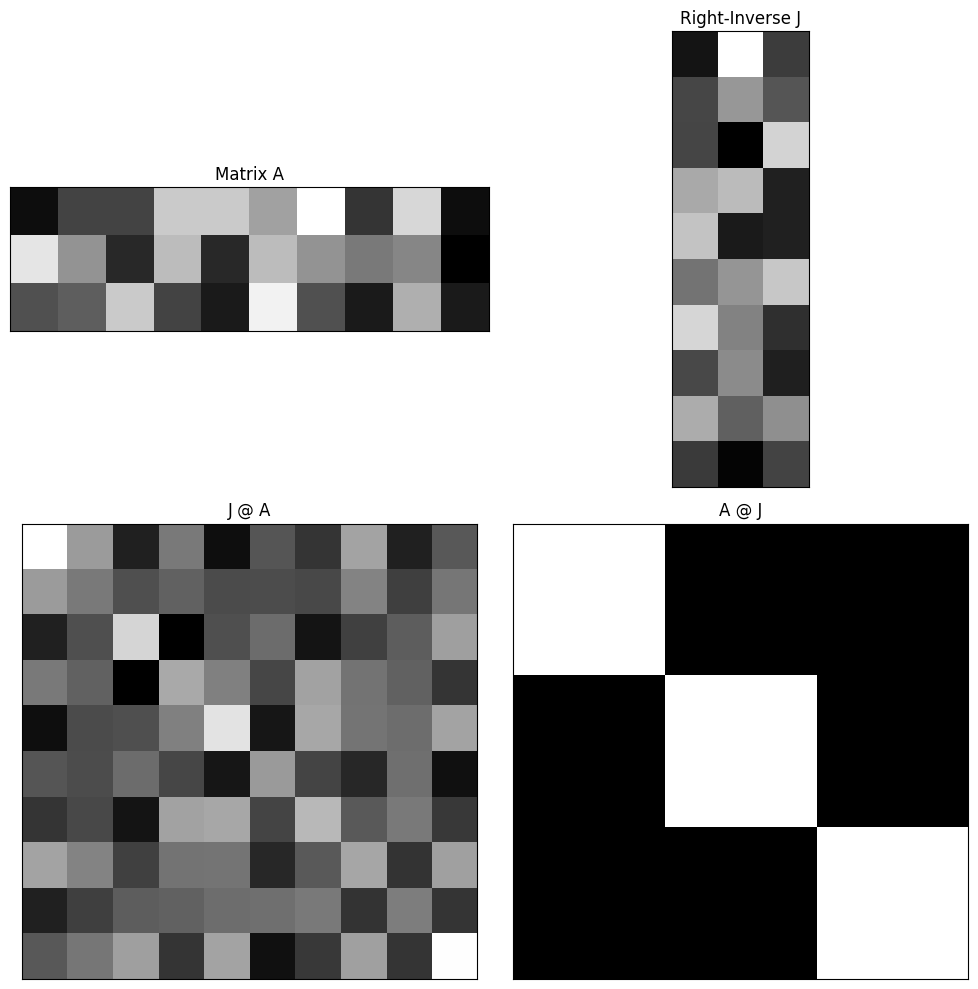

In [40]:
# Plot
fig, grid = plt.subplots(2, 2, figsize=(10, 10))

grid[0,0].imshow(A, cmap='gray')
grid[0,0].set_title('Matrix A')

grid[0,1].imshow(J, cmap='gray')
grid[0,1].set_title('Right-Inverse J')

grid[1,0].imshow(J @ A, cmap='gray')
grid[1,0].set_title('J @ A')

grid[1,1].imshow(A @ J, cmap='gray')
grid[1,1].set_title('A @ J')

for ax in grid.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

### Orthogonal Matrix & Norm

In [46]:
# Generate orthogonal matrix
U = np.linalg.qr(np.random.randn(3, 3))[0]
print("Original matrix:\n")
print(U)
print()
U_T = U.T
U_inv = np.linalg.inv(U)

print("Transpose:\n")
print(U_T)
print()

print("Inverse:\n")
print(U_inv)

Original matrix:

[[-0.65073102  0.08142441 -0.75492993]
 [-0.69681554 -0.45902647  0.55112867]
 [-0.30165749  0.88468343  0.35544056]]

Transpose:

[[-0.65073102 -0.69681554 -0.30165749]
 [ 0.08142441 -0.45902647  0.88468343]
 [-0.75492993  0.55112867  0.35544056]]

Inverse:

[[-0.65073102 -0.69681554 -0.30165749]
 [ 0.08142441 -0.45902647  0.88468343]
 [-0.75492993  0.55112867  0.35544056]]


In [47]:
# UᵀU
print(np.round(U_T @ U, 8))

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [48]:
# UUᵀ
print(np.round(U @ U_T, 8))

[[ 1.  0. -0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]


In [41]:
# Random orthogonal matrix
U, _ = np.linalg.qr(np.random.randn(5, 5))

# Norms of U
print("2-norm\t\t:", np.linalg.norm(U, 2))
print("Frobenius norm\t:", np.sqrt(np.sum(U**2)) / np.sqrt(5))

2-norm		: 1.0000000000000002
Frobenius norm	: 1.0


In [42]:
# Effect on vector norm
x = np.random.randn(5, 1)

x_norm = np.linalg.norm(x)
Ux_norm = np.linalg.norm(U @ x)

print(x_norm)
print(Ux_norm)

2.4035410741021543
2.4035410741021543
